#Ques/ans(1-5 & 10) Written baesd

#1. What is K-Nearest Neighbors (KNN) and how does it work in both classification and regression problems?
   - **K-Nearest Neighbors (KNN)** is a simple, non-parametric, supervised machine learning algorithm used for both **classification** and **regression** tasks. It works on the idea that similar data points exist close to each other in the feature space. When a new data point needs to be predicted, the algorithm calculates the distance (commonly using Euclidean distance) between the new point and all the points in the training dataset, then selects the **K closest neighbors**.
   
   - In **classification**, the algorithm assigns the class label that appears most frequently among these K nearest neighbors (majority voting). In **regression**, instead of voting, it predicts the output value by taking the **average (or sometimes weighted average)** of the target values of the K nearest neighbors. The choice of **K** is important because a small K may lead to noise and overfitting, while a large K may smooth out the prediction too much and cause underfitting. KNN is easy to understand and implement but can be computationally expensive for large datasets because it requires calculating distances to many points during prediction.

#2. What is the Curse of Dimensionality and how does it affect KNN performance?
   - The **Curse of Dimensionality** refers to the problems that arise when working with data that has a very large number of features (dimensions). As the number of dimensions increases, the data points become more spread out in the feature space, making it harder to measure meaningful distances between them.
   
   - This directly affects algorithms like **K-Nearest Neighbors (KNN)** because KNN relies on distance calculations to find the nearest neighbors. In high-dimensional spaces, the distance between data points tends to become very similar, reducing the algorithm’s ability to distinguish between close and far points. As a result, KNN may select neighbors that are not truly similar, leading to lower prediction accuracy and higher computational cost. Therefore, techniques like **feature selection** or **dimensionality reduction** (e.g., PCA) are often used to improve KNN performance when dealing with high-dimensional data.

#3.  What is Principal Component Analysis (PCA)? How is it different from feature selection?
   - **Principal Component Analysis (PCA)** is a dimensionality reduction technique used in machine learning and statistics to reduce the number of features in a dataset while preserving as much important information (variance) as possible. It works by transforming the original correlated features into a new set of uncorrelated variables called **principal components**. These components are linear combinations of the original features and are arranged in order of the amount of variance they capture from the data. The first principal component captures the highest variance, the second captures the next highest while being orthogonal to the first, and so on. By selecting only the top few principal components, PCA reduces the dimensionality of the dataset while retaining most of the useful information.

The main difference between **PCA** and **feature selection** is that PCA **creates new features** by combining the original ones, whereas feature selection **chooses a subset of the existing features** without modifying them. In feature selection, the original variables remain unchanged and only the most relevant ones are kept. In contrast, PCA transforms the data into a new feature space, which may make interpretation harder but often improves computational efficiency and reduces multicollinearity.

#4. What are eigenvalues and eigenvectors in PCA, and why are they important?
   - In **Principal Component Analysis (PCA)**, **eigenvalues** and **eigenvectors** are mathematical concepts used to identify the principal components of the dataset. When PCA is applied, the covariance matrix of the data is calculated, and then its eigenvalues and eigenvectors are computed. The **eigenvectors** represent the directions (principal components) in which the data varies the most, while the **eigenvalues** indicate the amount of variance or importance associated with each of those directions. In other words, each eigenvector defines a new axis in the transformed feature space, and its corresponding eigenvalue tells how much information (variance) is captured along that axis.

   - They are important because PCA selects the eigenvectors with the **largest eigenvalues** to form the principal components used for dimensionality reduction. By keeping only the components with the highest eigenvalues, PCA preserves the most significant patterns in the data while reducing the number of features, which improves efficiency and helps remove noise or redundant information.

#5. How do KNN and PCA complement each other when applied in a single pipeline?
   - **K-Nearest Neighbors (KNN)** and **Principal Component Analysis (PCA)** complement each other when used together in a machine learning pipeline because PCA helps reduce the dimensionality of the data before KNN performs prediction. KNN relies on distance calculations between data points, and when a dataset has many features, the **curse of dimensionality** can make these distance calculations less meaningful and computationally expensive. PCA addresses this problem by transforming the original features into a smaller set of principal components that capture most of the important variance in the data. By reducing the number of dimensions and removing noise or redundant information, PCA makes the dataset more compact and meaningful for distance-based algorithms like KNN. As a result, KNN can compute distances more efficiently, improve prediction accuracy, and reduce computation time when PCA is applied before it in the pipeline.

#10. You are working with a high-dimensional gene expression dataset to classify patients with different types of cancer.
#Due to the large number of features and a small number of samples, traditional models overfit.
##Explain how you would:
###● Use PCA to reduce dimensionality
###● Decide how many components to keep
###● Use KNN for classification post-dimensionality reduction
###● Evaluate the model
###● Justify this pipeline to your stakeholders as a robust solution for real-world biomedical data
(Include your Python code and output in the code box below.)
    - ---

### **Approach**

1. **Use PCA to reduce dimensionality**:

   * High-dimensional data (many genes) can lead to overfitting.
   * PCA transforms the dataset into **principal components** that capture the most variance.
   * This reduces noise and redundancy, keeping only the meaningful patterns.

2. **Decide how many components to keep**:

   * Use the **explained variance ratio** to select enough components to capture most of the variance (commonly 90–95%).
   * This balances retaining information with reducing dimensionality.

3. **Use KNN for classification**:

   * Train a **KNN classifier** on the PCA-transformed data.
   * Distance-based methods like KNN benefit from reduced dimensionality because the **curse of dimensionality** is mitigated.

4. **Evaluate the model**:

   * Use **train-test split** or **cross-validation** to estimate generalization performance.
   * Evaluate with metrics like **accuracy, precision, recall, F1-score**, or **confusion matrix** for biomedical relevance.

5. **Justify this pipeline**:

   * PCA reduces overfitting and noise while retaining biologically meaningful variation.
   * KNN is non-parametric and interpretable.
   * This pipeline is computationally efficient and robust for small-sample, high-dimensional biomedical data.

---
**Below the code is run**

#Ques/ans(6-10) practical based

In [4]:
#Dataset:
#Use the Wine Dataset from sklearn.datasets.load_wine().
#Question 6: Train a KNN Classifier on the Wine dataset with and without feature scaling. Compare model accuracy in both cases.
#(Include your Python code and output in the code box below.)

#Import libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 1. KNN WITHOUT feature scaling
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy_without_scaling = accuracy_score(y_test, y_pred)

print("Accuracy without feature scaling:", accuracy_without_scaling)


# -----------------------------
# 2. KNN WITH feature scaling
# -----------------------------
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_with_scaling = accuracy_score(y_test, y_pred_scaled)

print("Accuracy with feature scaling:", accuracy_with_scaling)


Accuracy without feature scaling: 0.7222222222222222
Accuracy with feature scaling: 0.9444444444444444


In [5]:
#Question:7
#Train a PCA model on the Wine dataset and print the explained variance ratio of each principal component.
#(Include your Python code and output in the code box below.)

# Import libraries
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Wine dataset
wine = load_wine()
X = wine.data

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Print explained variance ratio
print("Explained Variance Ratio of each Principal Component:")
print(pca.explained_variance_ratio_)


Explained Variance Ratio of each Principal Component:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


In [6]:
# Question 8: Train a KNN Classifier on the PCA-transformed dataset (retain top 2 components). Compare the accuracy with the original dataset.
#(Include your Python code and output in the code box below.)

# Import libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------
# 1. KNN on original (scaled) dataset
# ---------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
original_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy with original features:", original_accuracy)


# ---------------------------------------
# 2. Apply PCA (retain top 2 components)
# ---------------------------------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train KNN on PCA-transformed data
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

y_pred_pca = knn_pca.predict(X_test_pca)
pca_accuracy = accuracy_score(y_test, y_pred_pca)

print("Accuracy with PCA (2 components):", pca_accuracy)

Accuracy with original features: 0.9444444444444444
Accuracy with PCA (2 components): 1.0


In [7]:
# Question 9: Train a KNN Classifier with different distance metrics (euclidean, manhattan) on the scaled Wine dataset and compare the results.
#(Include your Python code and output in the code box below.)

# Import libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 1. KNN with Euclidean distance
# -----------------------------
knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train_scaled, y_train)

y_pred_euclidean = knn_euclidean.predict(X_test_scaled)
acc_euclidean = accuracy_score(y_test, y_pred_euclidean)

print("Accuracy with Euclidean distance:", acc_euclidean)


# -----------------------------
# 2. KNN with Manhattan distance
# -----------------------------
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train_scaled, y_train)

y_pred_manhattan = knn_manhattan.predict(X_test_scaled)
acc_manhattan = accuracy_score(y_test, y_pred_manhattan)

print("Accuracy with Manhattan distance:", acc_manhattan)

Accuracy with Euclidean distance: 0.9444444444444444
Accuracy with Manhattan distance: 0.9444444444444444


Number of components to retain 95% variance: 75
KNN Accuracy after PCA: 0.2

Classification Report:
               precision    recall  f1-score   support

           0       0.21      1.00      0.35         4
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         8

    accuracy                           0.20        20
   macro avg       0.07      0.33      0.12        20
weighted avg       0.04      0.20      0.07        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


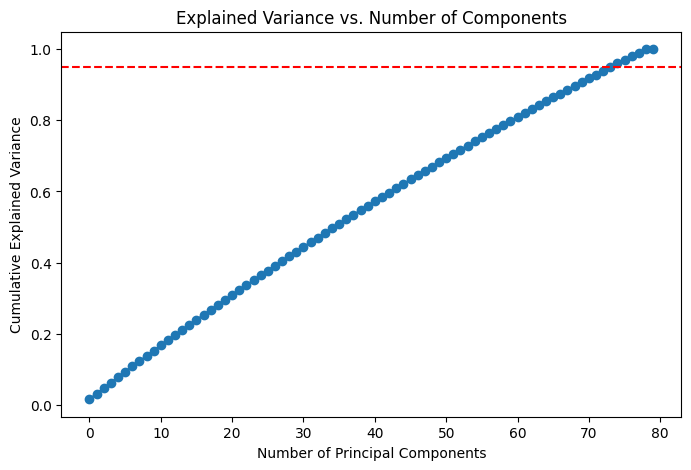

In [8]:
# Question 10: You are working with a high-dimensional gene expression dataset to classify patients with different types of cancer.
#Due to the large number of features and a small number of samples, traditional models overfit.
#(Include your Python code and output in the code box below.)

# Import libraries
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Simulate a high-dimensional gene expression dataset
X, y = make_classification(n_samples=100, n_features=5000, n_informative=50,
                           n_redundant=0, n_classes=3, random_state=42)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Decide how many components to keep (e.g., 95% variance)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components to retain 95% variance:", n_components)

# Reduce dimensionality
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train KNN on PCA-transformed data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print("KNN Accuracy after PCA:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Optional: plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()